# Extended Data Figure 1

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
from scipy.interpolate import interp2d
from scipy.ndimage.filters import gaussian_filter

# Set colour palette:
pal = sns.diverging_palette(250, 13, s=100, l=35, sep=8, center='light', as_cmap=True)

# Load receptive fields of input cells from Fig. 1:
os.chdir('../Fig. 1')
RFs = np.load('fig1d_receptive_fields.npy', allow_pickle=True, encoding='latin1')[()]

# Sepcify timeframe tmin to tmax (* 16.667 ms because of the 60 Hz)
def time_avg(rf, tmin=-6 , tmax=0): 
    avg_rf = rf[:,:,180+tmin:180+tmax,:].mean(2)
    return avg_rf

Mi9_RFs  = time_avg(RFs['Mi9'])
Tm3_RFs  = time_avg(RFs['Tm3'])
Mi1_RFs  = time_avg(RFs['Mi1'])
Mi4_RFs  = time_avg(RFs['Mi4'])
C3_RFs  = time_avg(RFs['C3'])

# Load receptive fields of T4 cells:
T4_RFs  = time_avg(np.load('fig1e_receptive_fields.npy'))
os.chdir('../ED Fig. 1')

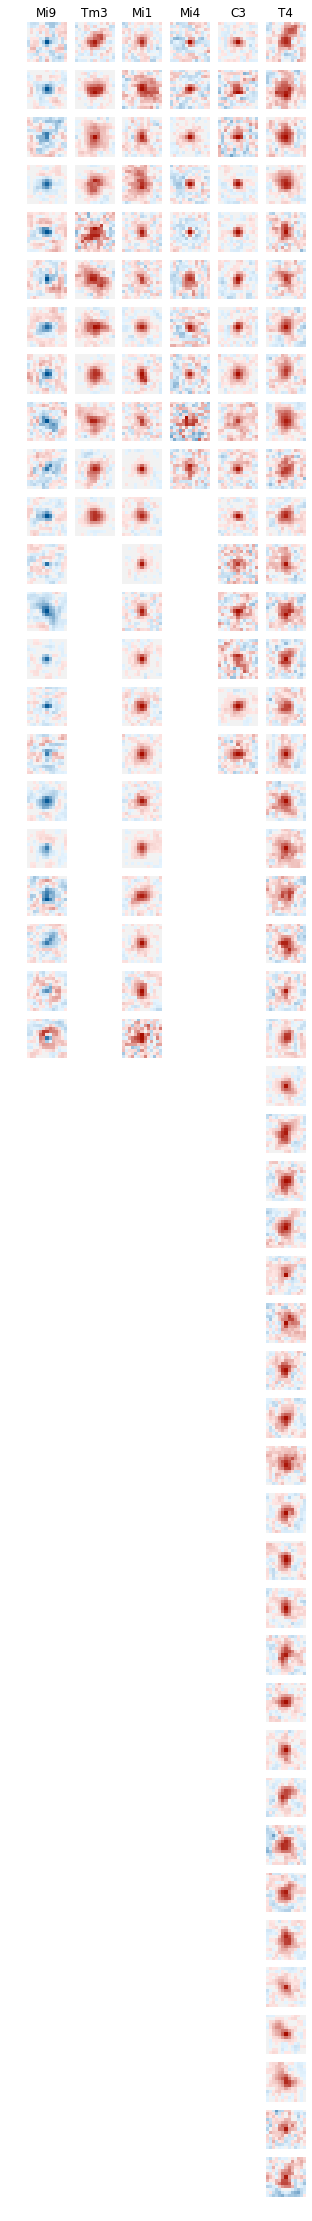

In [2]:
# Extended Data Figure 1b:
data = [Mi9_RFs, Tm3_RFs, Mi1_RFs, Mi4_RFs, C3_RFs]
names = ['Mi9', 'Tm3', 'Mi1', 'Mi4', 'C3']

n_max = T4_RFs.shape[2]

fig, ax = plt.subplots(n_max,len(data)+1,figsize=(5,40))
for idxd, d in enumerate(data):
    ax[0, idxd].set_title(names[idxd])
    for cell in range(d.shape[2]):
        ax[cell, idxd].imshow(d[:,:,cell], vmin=-0.75, vmax=0.75, cmap = pal, origin='lower')
for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        ax[i, j].axis('off')

for cell in range(T4_RFs.shape[2]):
    ax[cell, -1].imshow(T4_RFs[2:-2, 2:-2,cell], vmin = -0.75, vmax = 0.75, cmap = pal, origin='lower')
    ax[cell,-1].axis('off')
ax[0, -1].set_title('T4');